In [3]:
# Standard data tools
import numpy as np                   
import pandas as pd                  

# Visualisation tools 
import matplotlib.pyplot as plt      
import matplotlib.cm as cm
import seaborn as sns  
import missingno as msno # Missing data - Data visualization
import re
import math

# Settings 
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [4]:
# Load Data

job_df = pd.read_csv("jobs_dataset.csv")

In [5]:
# Convert all column names to lowercase
job_df.columns = job_df.columns.str.lower()

print("✅ All table column names converted to lowercase.")

✅ All table column names converted to lowercase.


### Data Exploration & Cleaning

### Data Structure Validation

In [6]:
# Index to assess the position of values inside a list

print(f"Dataset shape: {job_df.shape[0]:,} rows x {job_df.shape[1]:,} columns")

Dataset shape: 4,653 rows x 17 columns


In [7]:
# Standardize column names
job_df.columns = (
    job_df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
)

In [8]:
# View All the Data Types 
job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               4653 non-null   int64  
 1   job_title            4653 non-null   object 
 2   company              4652 non-null   object 
 3   location             4653 non-null   object 
 4   salary_min           2299 non-null   float64
 5   salary_max           2295 non-null   float64
 6   description          4653 non-null   object 
 7   country              4653 non-null   object 
 8   search_keyword       4653 non-null   object 
 9   experience_required  487 non-null    float64
 10  degree_required      4653 non-null   object 
 11  skills               4653 non-null   object 
 12  num_skills           4653 non-null   int64  
 13  job_level            4653 non-null   object 
 14  is_remote            4653 non-null   bool   
 15  salary_avg           2299 non-null   f

In [9]:
# Describe the entire data 

job_df.describe(include="all")

,job_id,job_title,company,location,salary_min,salary_max,description,country,search_keyword,experience_required,degree_required,skills,num_skills,job_level,is_remote,salary_avg,has_salary
count,4.653000e+03,4653,4652,4653,2.299000e+03,2.295000e+03,4653,4653,4653,487.000000,4653,4653,4653.000000,4653,4653,2.299000e+03,4653
unique,NaN,1513,1851,833,NaN,NaN,3361,5,5,NaN,4,51,NaN,4,2,NaN,2
top,NaN,data engineer,ITonlinelearning Recruitment,"Bangalore, Karnataka",NaN,NaN,Trainee Business Analyst Programme – Job Guara...,USA,data scientist,NaN,Not specified,[],NaN,Mid,False,NaN,False
freq,NaN,445,256,295,NaN,NaN,130,950,950,NaN,4444,3244,NaN,3442,4274,NaN,2358
mean,5.639829e+09,NaN,NaN,NaN,1.171822e+05,1.491949e+05,NaN,NaN,NaN,23.969199,NaN,NaN,0.383838,NaN,NaN,1.330675e+05,NaN
std,3.094779e+08,NaN,NaN,NaN,1.826840e+05,3.461697e+05,NaN,NaN,NaN,60.676816,NaN,NaN,0.680850,NaN,NaN,2.554015e+05,NaN
min,1.155088e+09,NaN,NaN,NaN,0.000000e+00,1.100000e+01,NaN,NaN,NaN,1.000000,NaN,NaN,0.000000,NaN,NaN,1.000000e+01,NaN
25%,5.679737e+09,NaN,NaN,NaN,5.301667e+04,5.720662e+04,NaN,NaN,NaN,5.000000,NaN,NaN,0.000000,NaN,NaN,5.508915e+04,NaN
50%,5.696178e+09,NaN,NaN,NaN,8.288952e+04,9.118422e+04,NaN,NaN,NaN,7.000000,NaN,NaN,0.000000,NaN,NaN,8.822215e+04,NaN
75%,5.704005e+09,NaN,NaN,NaN,1.358604e+05,1.450000e+05,NaN,NaN,NaN,12.000000,NaN,NaN,1.000000,NaN,NaN,1.403207e+05,NaN


### Data Quality Validation

In [10]:
# View missing data
job_df.isnull().sum()

job_id                    0
job_title                 0
company                   1
location                  0
salary_min             2354
salary_max             2358
description               0
country                   0
search_keyword            0
experience_required    4166
degree_required           0
skills                    0
num_skills                0
job_level                 0
is_remote                 0
salary_avg             2354
has_salary                0
dtype: int64

In [11]:
# Weigh missing values

missing = (
    job_df
    .isnull()
    .sum()
    .to_frame("Missing")
)

missing["% Missing"] = (
    missing["Missing"] /
    len(job_df)*100
).round(2)

missing = missing.sort_values(
    "% Missing",
    ascending=False
)

# Displaying values > 0.0
missing[missing["% Missing"] > 0.0]

,Missing,% Missing
experience_required,4166,89.53
salary_max,2358,50.68
salary_avg,2354,50.59
salary_min,2354,50.59
company,1,0.02


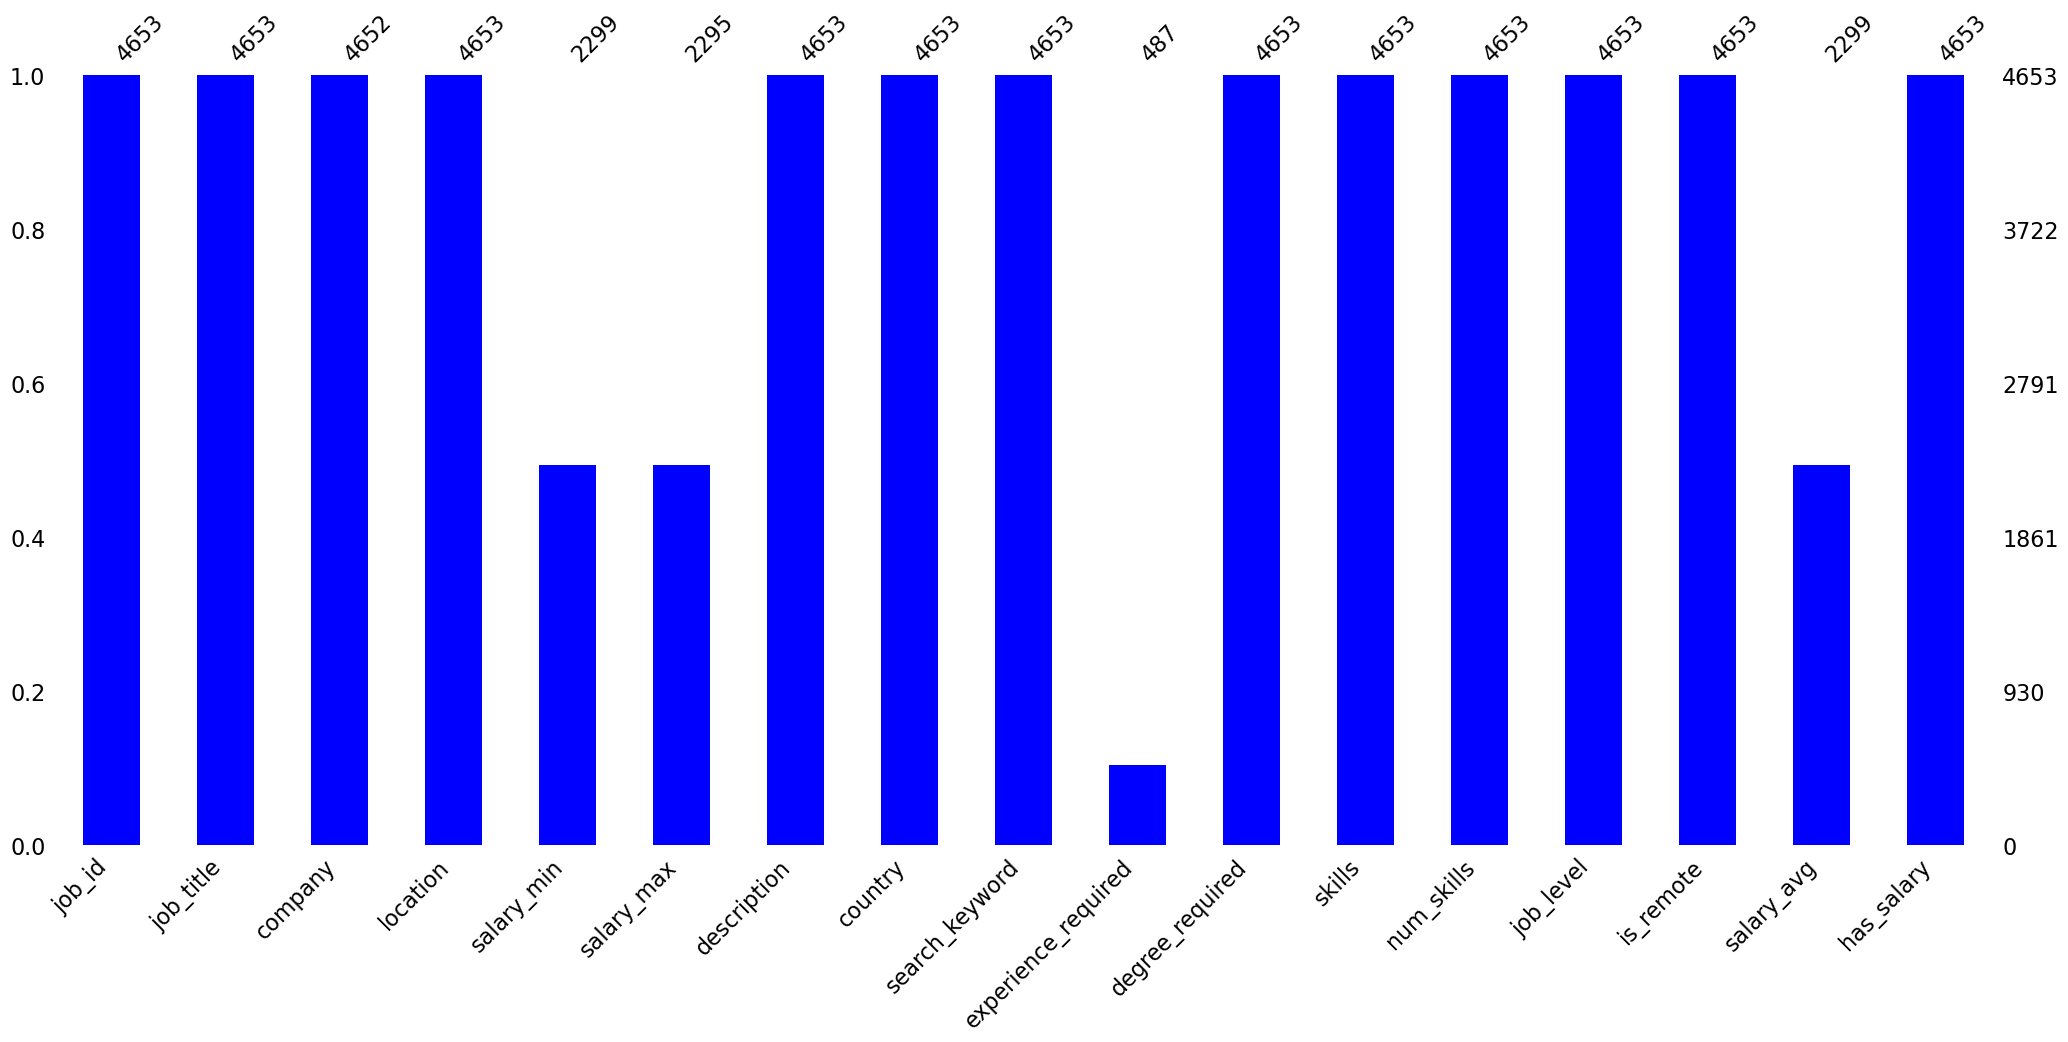

In [12]:
# Visualize as a Bar plot

msno.bar(job_df, color="blue")
plt.show()

In [13]:
# View duplicates
job_df.duplicated().sum()

np.int64(0)

In [14]:
job_df["experience_required"].nunique()

42

In [15]:
# Cleaning by order of priority
job_df["country"].value_counts(dropna=False)

country
USA          950
UK           949
Canada       935
India        916
Australia    903
Name: count, dtype: int64

In [16]:
job_df["country"] = (
    job_df["country"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

In [17]:
job_df["country"]

0           India
1           India
2           India
3           India
4           India
          ...    
4648    Australia
4649    Australia
4650    Australia
4651    Australia
4652    Australia
Name: country, Length: 4653, dtype: object

In [18]:
job_df["search_keyword"].value_counts(dropna=False)

search_keyword
data scientist               950
business analyst             939
data analyst                 933
data engineer                933
machine learning engineer    898
Name: count, dtype: int64

In [19]:
job_df["search_keyword"] = (
    job_df["search_keyword"]
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

In [20]:
job_df["search_keyword"].unique()

array(['data scientist', 'data analyst', 'data engineer',
       'machine learning engineer', 'business analyst'], dtype=object)

In [21]:
job_df["job_level"].value_counts(dropna=False)

job_level
Mid       3442
Senior     846
Lead       293
Junior      72
Name: count, dtype: int64

In [22]:
job_df["job_level"] = (
    job_df["job_level"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

In [23]:
job_df["job_level"].unique()

array(['Mid', 'Lead', 'Senior', 'Junior'], dtype=object)

In [24]:
job_df["degree_required"].value_counts(dropna=False)

degree_required
Not specified    4444
Master            174
Bachelor           29
PhD                 6
Name: count, dtype: int64

In [25]:
job_df["degree_required"] = (
    job_df["degree_required"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

In [26]:
degree_mapping = {
    "Bachelors": "Bachelor's",
    "Bachelor Degree": "Bachelor's",
    "Masters": "Master's",
    "Master Degree": "Master's"
}

job_df["degree_required"] = (
    job_df["degree_required"]
    .replace(degree_mapping)
)

In [27]:
job_df["company"].value_counts(dropna=False)

company
ITonlinelearning Recruitment                    256
Indeed                                          119
Booz Allen Hamilton                             105
Insight Global                                   89
Targeted Talent                                  78
                                               ... 
STAFFXPERT LLC                                    1
Nabors                                            1
American Association Of Motor Vehicle Admin.      1
IO Datasphere                                     1
SunWater                                          1
Name: count, Length: 1852, dtype: int64

### EDA

#### Univariate Analysis

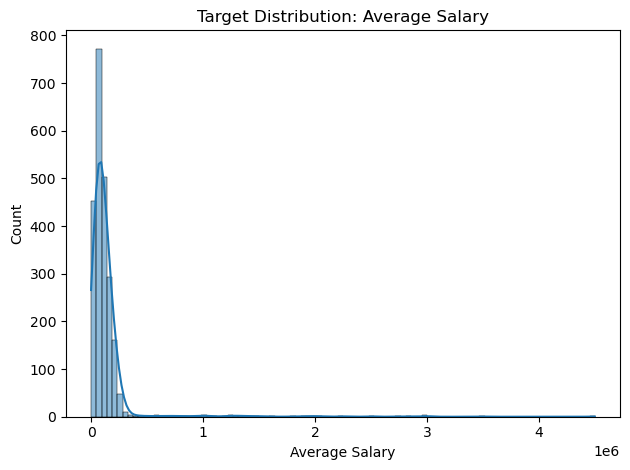

In [28]:
sns.histplot(data=job_df, x="salary_avg", kde=True)
plt.title("Target Distribution: Average Salary")
plt.xlabel("Average Salary")
plt.tight_layout()
plt.show()

In [29]:
job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               4653 non-null   int64  
 1   job_title            4653 non-null   object 
 2   company              4652 non-null   object 
 3   location             4653 non-null   object 
 4   salary_min           2299 non-null   float64
 5   salary_max           2295 non-null   float64
 6   description          4653 non-null   object 
 7   country              4653 non-null   object 
 8   search_keyword       4653 non-null   object 
 9   experience_required  487 non-null    float64
 10  degree_required      4653 non-null   object 
 11  skills               4653 non-null   object 
 12  num_skills           4653 non-null   int64  
 13  job_level            4653 non-null   object 
 14  is_remote            4653 non-null   bool   
 15  salary_avg           2299 non-null   f

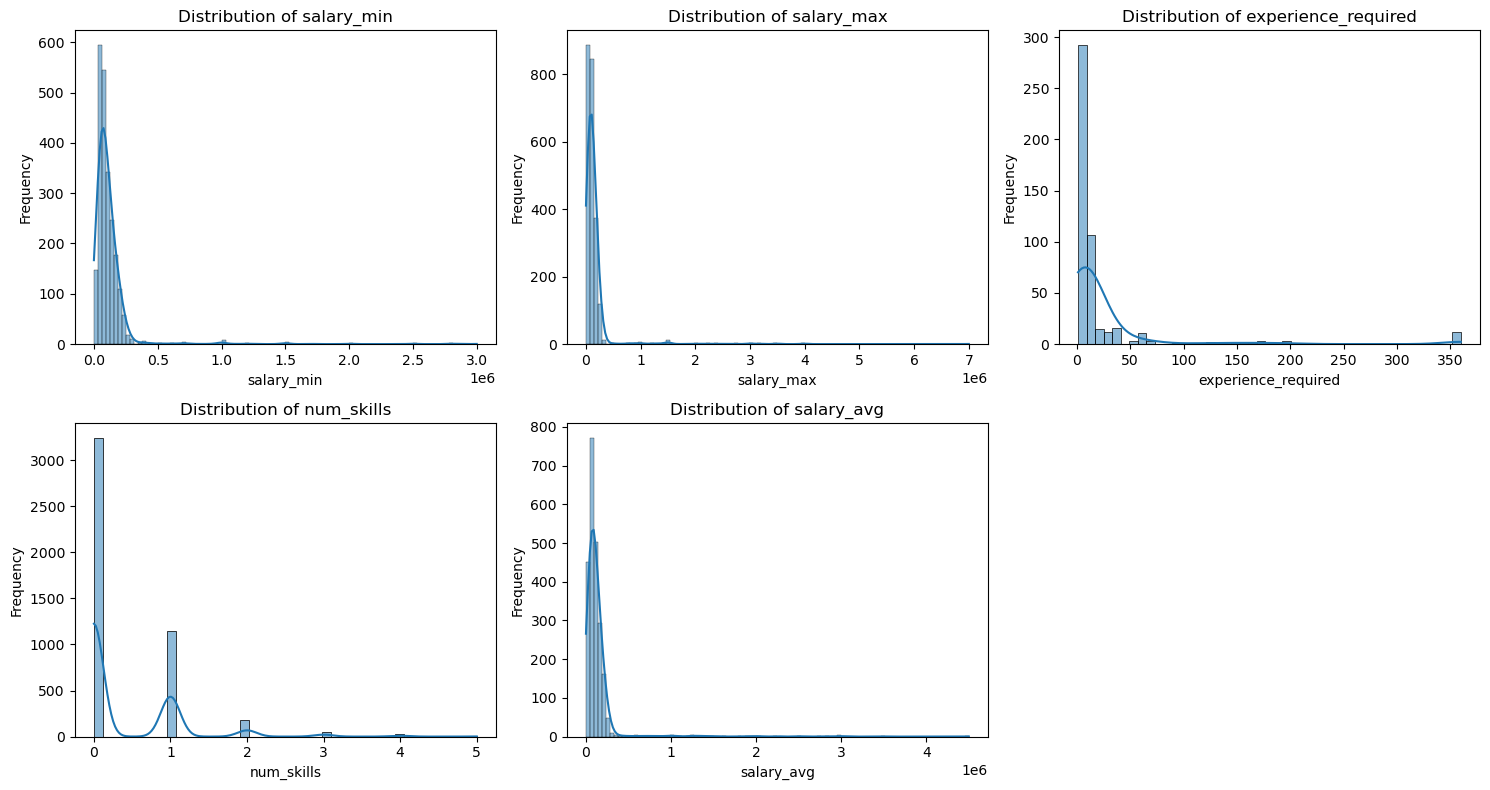

In [30]:

# Select numerical columns (excluding specified columns)
num_cols = (
    job_df
    .select_dtypes(include=np.number)
    .drop(columns=["job_id", "has_salary", "is_remote"],
         errors="ignore"
         )
    .columns
)

# Define subplot arrangement
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = np.ravel(axes)

# Plot each numerical column
for ax, col in zip(axes, num_cols):
    sns.histplot(
        data=job_df,
        x=col,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

# Remove unused axes
for ax in axes[len(num_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

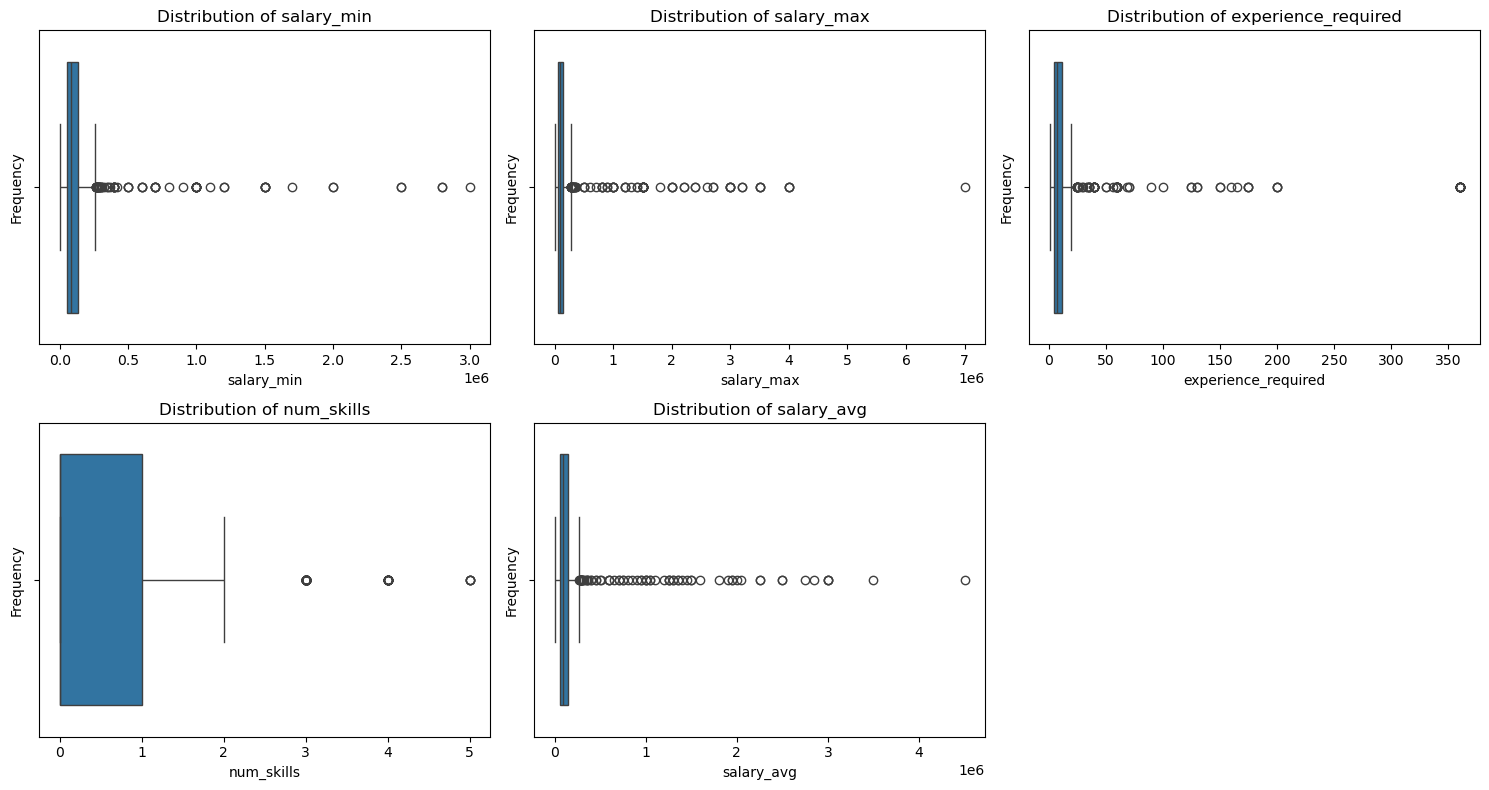

In [31]:

# Select numerical columns (excluding specified columns)
num_cols = (
    job_df
    .select_dtypes(include=np.number)
    .drop(columns=["job_id", "has_salary", "is_remote"],
         errors="ignore"
         )
    .columns
)

# Define subplot arrangement
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = np.ravel(axes)

# Plot each numerical column
for ax, col in zip(axes, num_cols):
    sns.boxplot(
        data=job_df,
        x=col,
        ax=ax
    )

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

# Remove unused axes
for ax in axes[len(num_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [32]:
# Count the values for Countries
job_df["country"].value_counts()

country
USA          950
UK           949
Canada       935
India        916
Australia    903
Name: count, dtype: int64

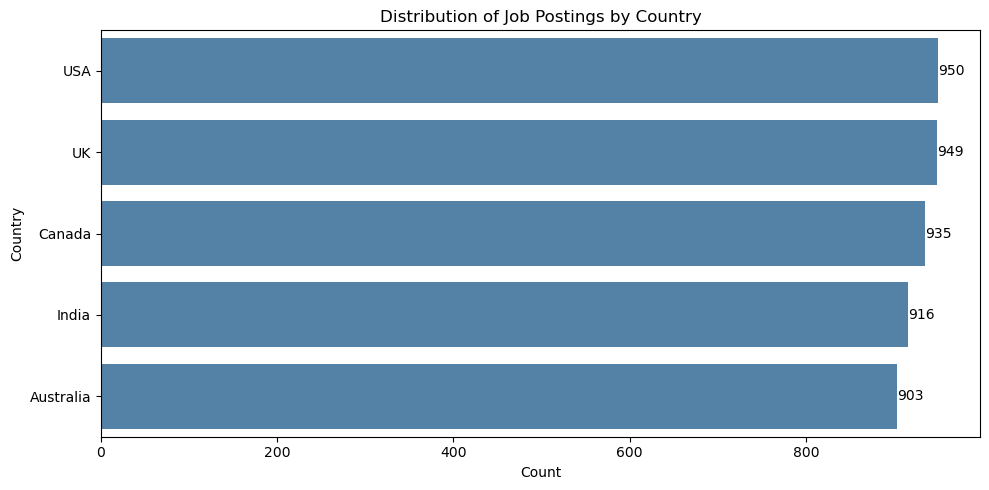

In [33]:
# Distribution by Country
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=job_df,
    y="country",
    order=job_df["country"].value_counts().index,
    color="steelblue"
)

# Add value labels
ax.bar_label(ax.containers[0])

plt.title("Distribution of Job Postings by Country")
plt.xlabel("Count")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

skills
[]                                3244
['machine learning']               727
['excel']                          161
['sql']                             93
['python', 'sql']                   89
['python']                          72
['aws']                             51
['python', 'machine learning']      27
['python', 'sql', 'spark']          21
['spark']                           19
Name: count, dtype: int64


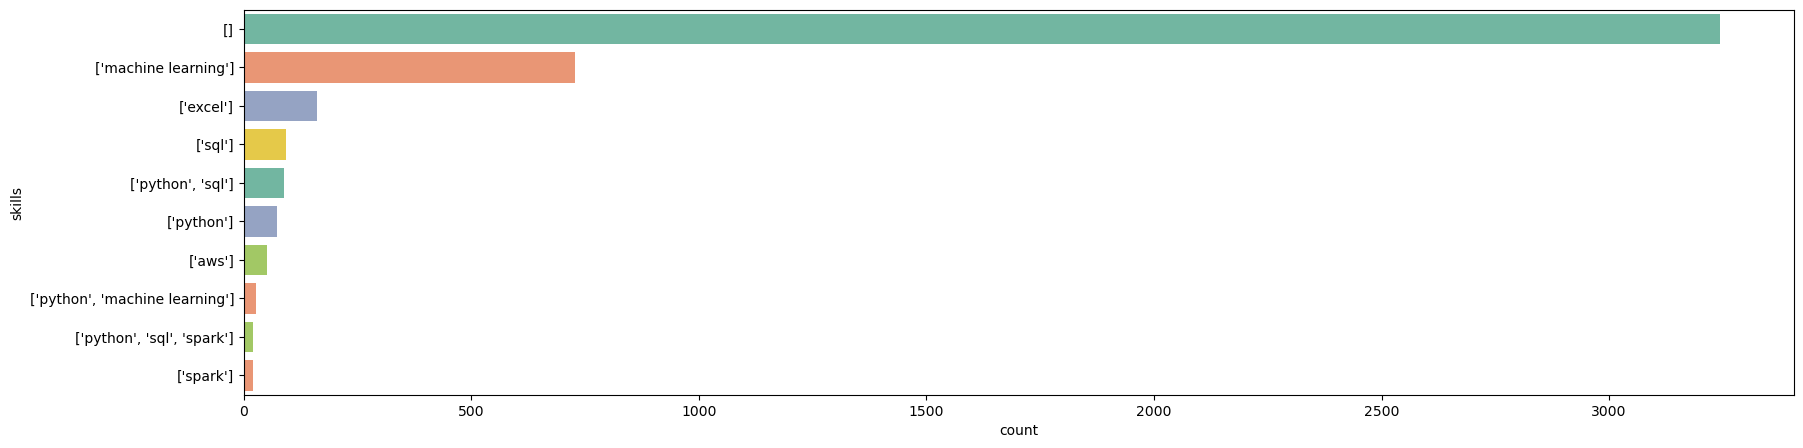

In [34]:
# Total Top 10 skills by Country
plt.figure(figsize=(20, 5))
topten = job_df["skills"].value_counts().head(10)
sns.countplot(y="skills", data=job_df, order=topten.index, hue="skills", palette="Set2", legend=False)
print(topten)

In [35]:
job_df.head(2)

,job_id,job_title,company,location,salary_min,salary_max,description,country,search_keyword,experience_required,degree_required,skills,num_skills,job_level,is_remote,salary_avg,has_salary
0,5710345523,data scientist,Empnéo ICT,India,NaN,NaN,Job description Lead Data Scientist — Analytic...,India,data scientist,8.0,Not Specified,[],0,Mid,False,NaN,False
1,5676535670,data scientist,ADM,"Bangalore, Karnataka",NaN,NaN,"Data Scientist Bengaluru, India Position Summa...",India,data scientist,NaN,Not Specified,[],0,Mid,False,NaN,False


#### Bivariate Analysis

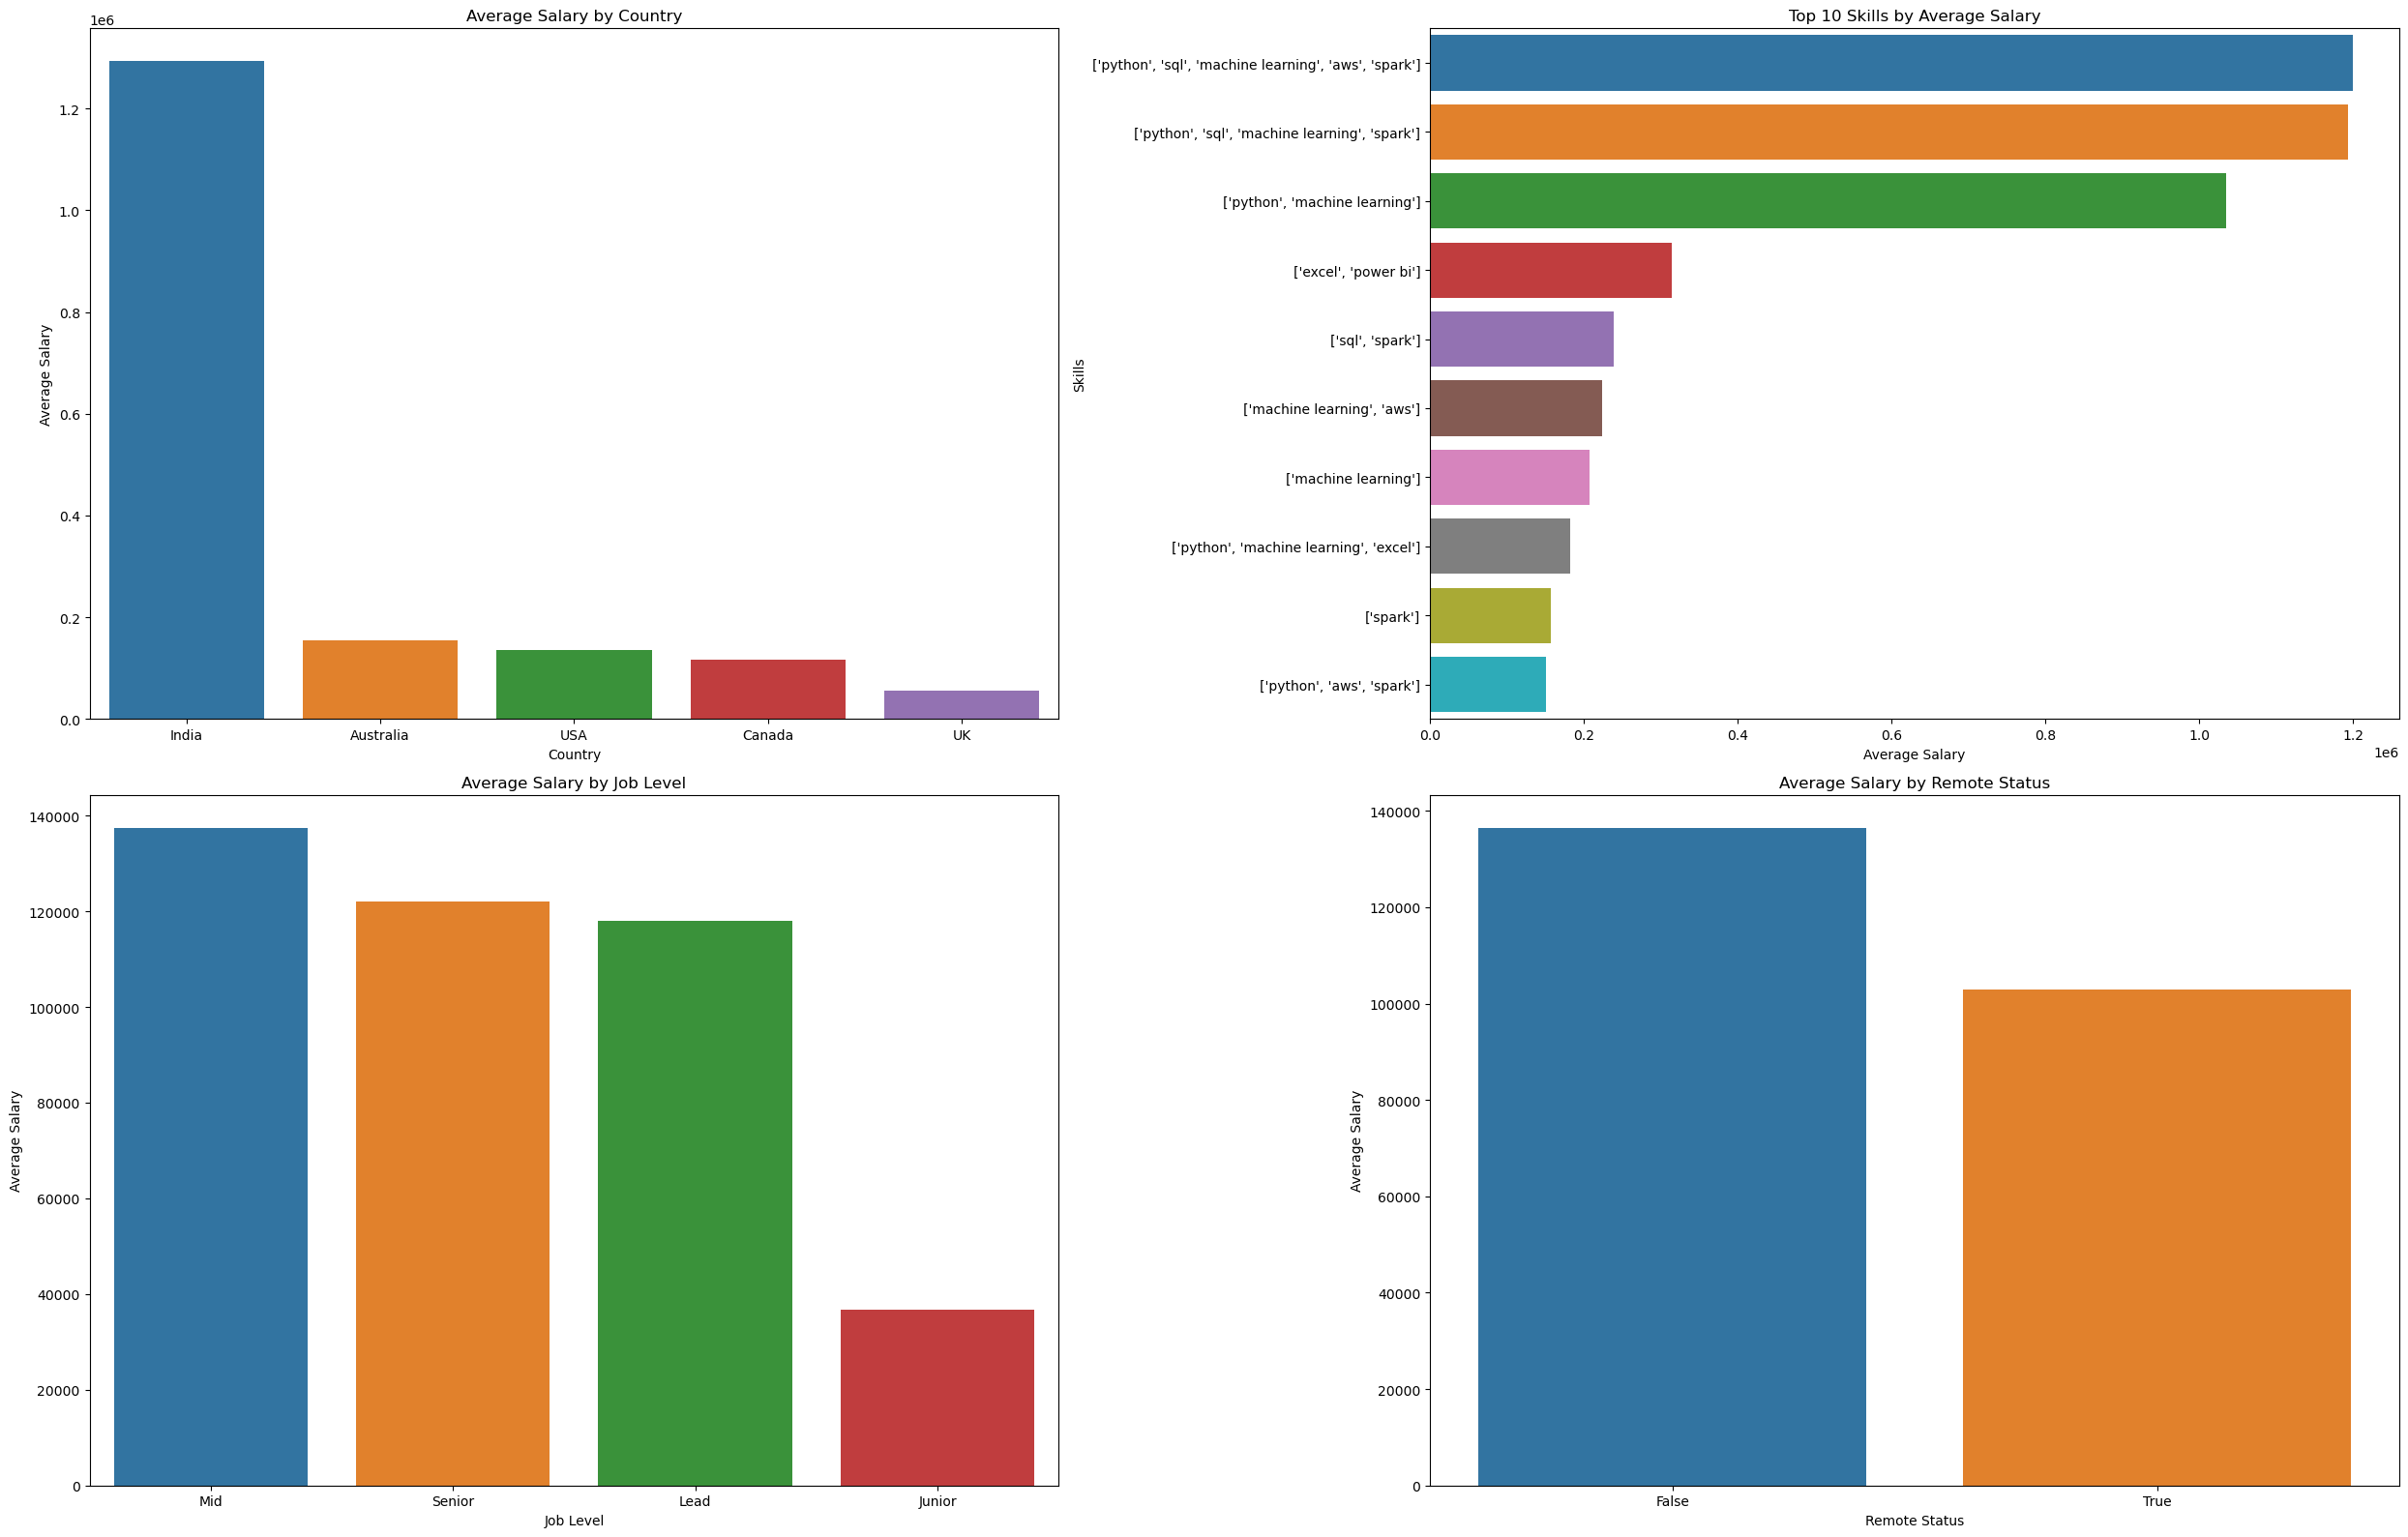

In [57]:
# Combining Two Variables

fig, axs = plt.subplots(nrows=2,ncols=2,figsize=(25, 16))

# Average Salary by Country

country_salary = (
    job_df
    .groupby("country", as_index=False)["salary_avg"]
    .mean()
    .sort_values("salary_avg", ascending=False)
)

sns.barplot(
    data=country_salary,
    x="country",
    y="salary_avg",
    hue="country",
    order=country_salary["country"],
    legend=False,
    ax=axs[0, 0]
)

axs[0, 0].set_title("Average Salary by Country")
axs[0, 0].set_xlabel("Country")
axs[0, 0].set_ylabel("Average Salary")


# Top 10 Skills by Average Salary

skill_salary = (
    job_df
    .groupby("skills", as_index=False)["salary_avg"]
    .mean()
    .sort_values("salary_avg", ascending=False)
)

top10 = skill_salary.head(10)

sns.barplot(
    data=top10,
    y="skills",
    x="salary_avg",
    hue="skills",
    order=top10["skills"],
    legend=False,
    ax=axs[0, 1]
)

axs[0, 1].set_title("Top 10 Skills by Average Salary")
axs[0, 1].set_xlabel("Average Salary")
axs[0, 1].set_ylabel("Skills")


# Average Salary by Job Level

job_salary = (
    job_df
    .groupby("job_level", as_index=False)["salary_avg"]
    .mean()
    .sort_values("salary_avg", ascending=False)
)

sns.barplot(
    data=job_salary,
    x="job_level",
    y="salary_avg",
    hue="job_level",
    order=job_salary["job_level"],
    legend=False,
    ax=axs[1, 0]
)

axs[1, 0].set_title("Average Salary by Job Level")
axs[1, 0].set_xlabel("Job Level")
axs[1, 0].set_ylabel("Average Salary")


# Average Salary by Remote Status

remote_salary = (
    job_df
    .groupby("is_remote", as_index=False)["salary_avg"]
    .mean()
    .sort_values("salary_avg", ascending=False)
)

sns.barplot(
    data=remote_salary,
    x="is_remote",
    y="salary_avg",
    hue="is_remote",
    legend=False,
    ax=axs[1, 1]
)

axs[1, 1].set_title("Average Salary by Remote Status")
axs[1, 1].set_xlabel("Remote Status")
axs[1, 1].set_ylabel("Average Salary")


plt.tight_layout()
plt.show()

In [54]:
# Count the values for Countries
job_df["is_remote"].value_counts()

is_remote
False    4274
True      379
Name: count, dtype: int64

KeyError: 'skills'

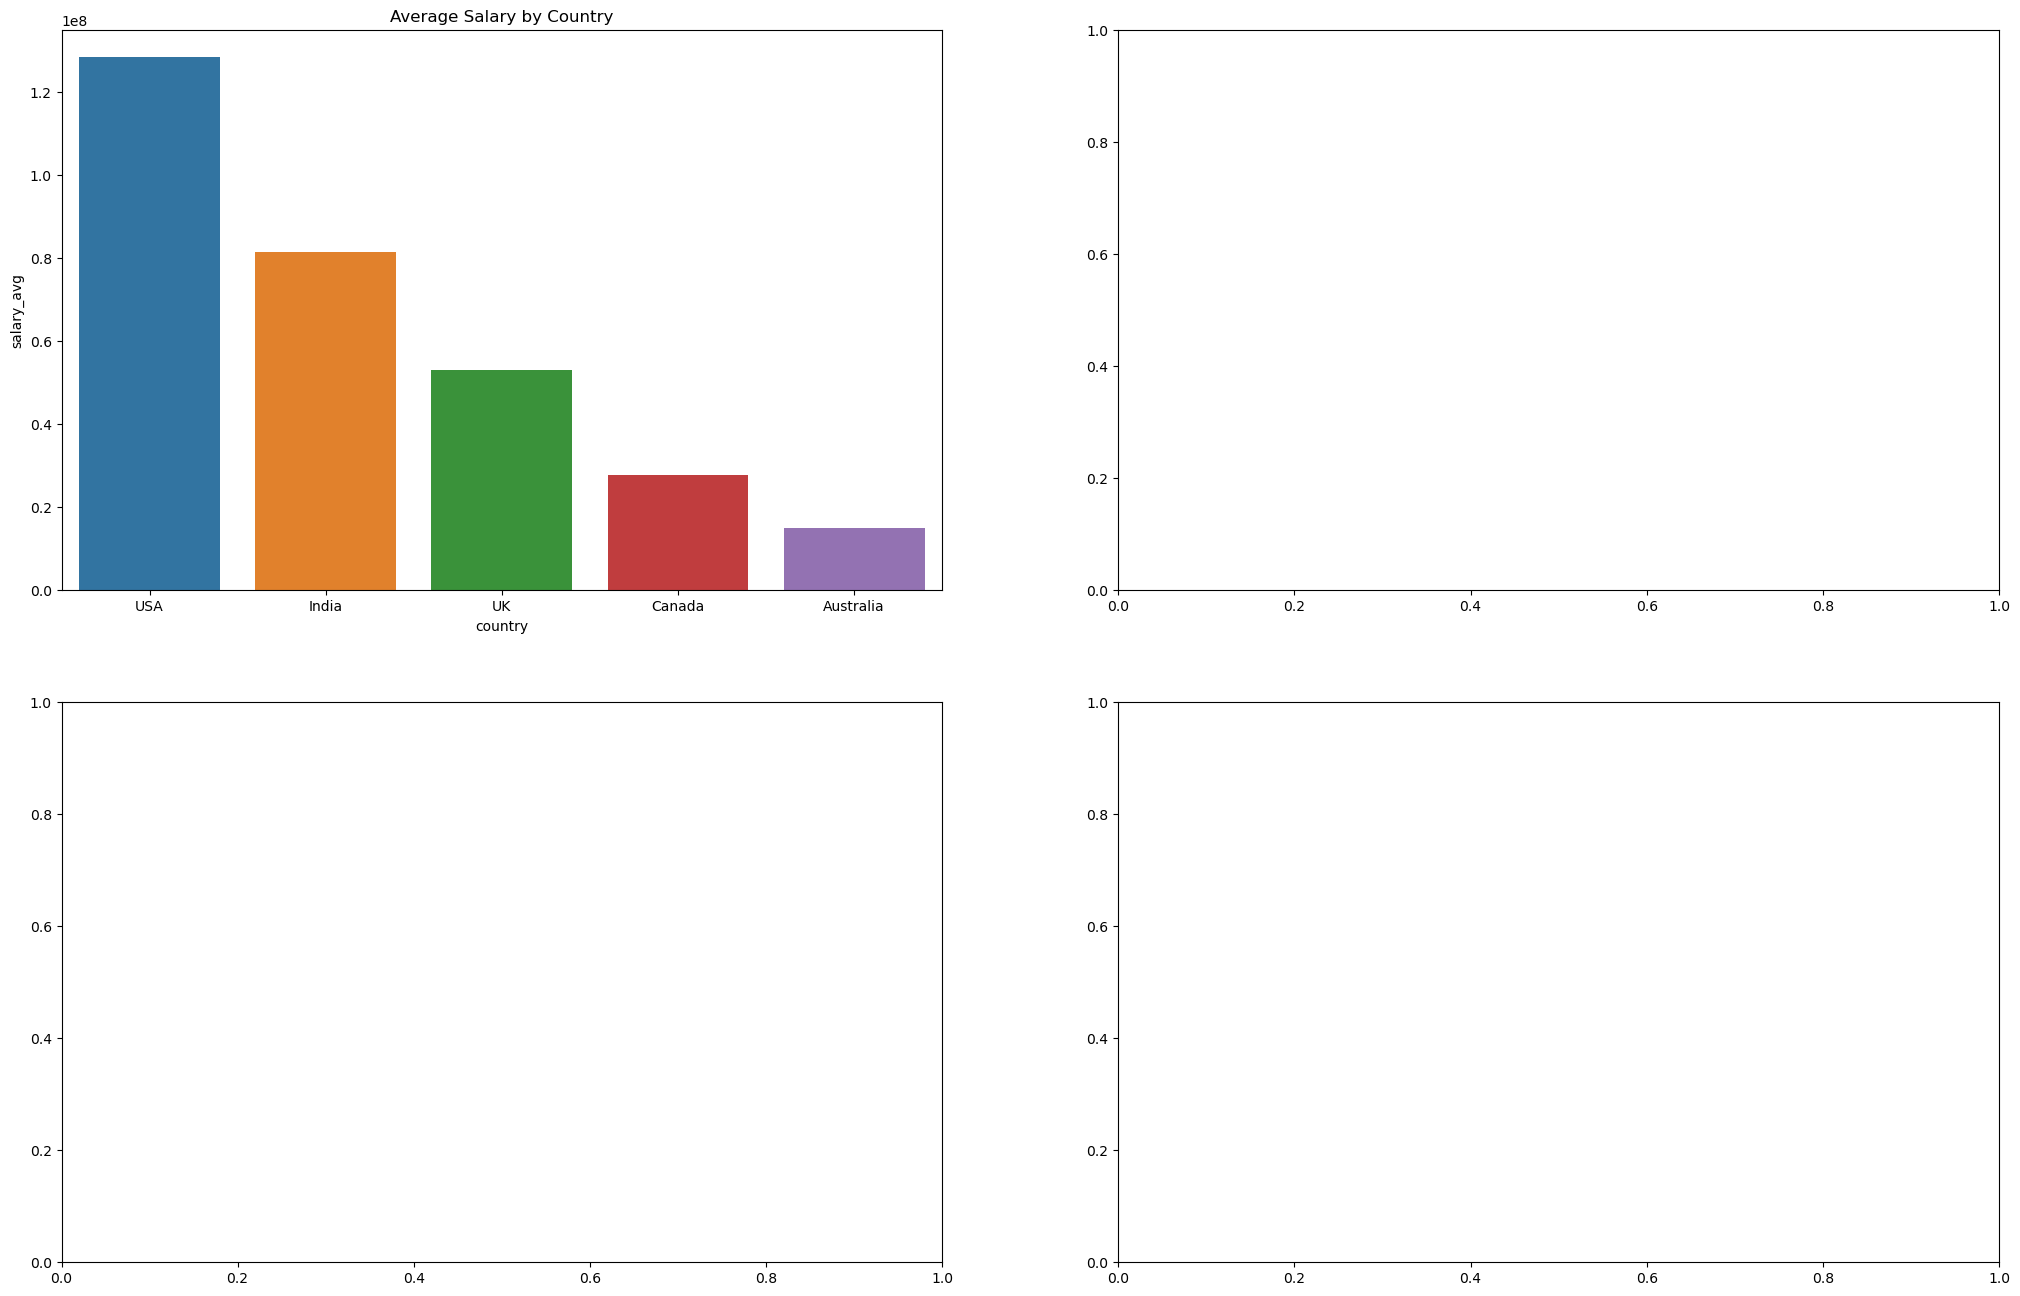

In [51]:
# Combining Two Variables

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(25, 16))

# Create a variable that groups sums Average Salary based on Country
country_salary = job_df.groupby(
    "country")["salary_avg"].sum().reset_index().sort_values(
            "salary_avg", 
            ascending=False
        )

country_salary

# Plot a bar chart of Country against Average Salary
sns.barplot(x="country", 
            data=country_salary, 
            y="salary_avg", 
            ax=axs[0,0], 
            hue="country")

axs[0,0].set_title("Average Salary by Country")


# Create a variable that groups sums Average Salary based on Skills
skill_salary = job_df.groupby(
    "skills", as_index=False)["salary_avg"].sum().sort_values(
            "salary_avg", 
            ascending=False
        )

skill_salary

# Plot a bar chart of Skills against Average Salary
top10 = skill_salary.head(10)

sns.barplot(y="skills", 
            data=topten, 
            x="salary_avg", 
            ax=axs[0,1], 
            hue="skills", 
            order=topten["skills"])

axs[0,1].set_title("Average Salary by Skills")


# Create a variable that groups sums Average Salary based on Job Level
job_salary = job_df.groupby(
    "job_level")["salary_avg"].sum().reset_index().sort_values(
            "salary_avg", 
            ascending=False
        )

job_salary

# Plot a bar chart of Country against Average Salary
sns.barplot(x="job_level", 
            data=job_salary, 
            y="salary_avg", 
            ax=axs[1,0], 
            hue="job_level")

axs[1,0].set_title("Average Salary by Job Level")


# Create a variable that groups sums Average Salary based on is_Remote
remote_salary = job_df.groupby(
    "is_remote")["salary_avg"].sum().reset_index()

remote_salary

# Plot a pie chart of Remote against Average Salary
axs[1,1].pie(remote_salary["salary_avg"], 
             labels=remote_salary["is_remote"],
             autopct="%1.1f%%", 
             startangle=90, 
             wedgeprops={
                 'width':0.45,
                 'edgecolor': 'white'
             }
            )
axs[1,1].set_title("Average salary Distribution by is_remote")



plt.tight_layout()
plt.show()